# _Segmentaçõ, Carregamento do Dataset...._

# ⬇️ | Imports

In [2]:
import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from pathlib import Path

# ⬇️ | Dataset

In [3]:
## dataset disponivel no Kaggle
## Kaggle - https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification/data

## Diretorio referente ao dataset.
TRAIN_PATH = Path("dataset/train")   ## na hora de entregar se for deixar diferente mudar o diretorio
TEST_PATH = Path("dataset/test")     ## coloca o ../ para voltar uma pasta

print("Train existe:", TRAIN_PATH.exists())
print("Test existe :", TEST_PATH.exists())

Train existe: True
Test existe : True


# ⬇️ | Classes


In [4]:
# TIPO DAS CLASSES
classes = []

for pasta in TRAIN_PATH.iterdir():

    if pasta.is_dir():
        classes.append(pasta.name)

print(classes)

['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


In [5]:
# Quantas Imagens tem por Classes
dados = []

for pasta in TRAIN_PATH.iterdir():

    if pasta.is_dir():

        quantidade = 0

        quantidade += len(list(pasta.glob("*.jpg")))
        quantidade += len(list(pasta.glob("*.jpeg")))
        quantidade += len(list(pasta.glob("*.png")))

        dados.append({
            "classe": pasta.name,
            "quantidade": quantidade
        })

df_classes = pd.DataFrame(dados)

df_classes

,classe,quantidade
0,freshapples,1693
1,freshbanana,1581
2,freshoranges,1466
3,rottenapples,2342
4,rottenbanana,2224
5,rottenoranges,1595


In [6]:
# Total de Podres e Fresca de Todas as FRUTAS
fresh = 0
rotten = 0

for _, linha in df_classes.iterrows():

    classe = linha["classe"].lower()

    if "fresh" in classe:
        fresh += linha["quantidade"]

    elif "rotten" in classe:
        rotten += linha["quantidade"]

print("Fresh :", fresh)
print("Rotten:", rotten)

Fresh : 4740
Rotten: 6161


## Gráficos

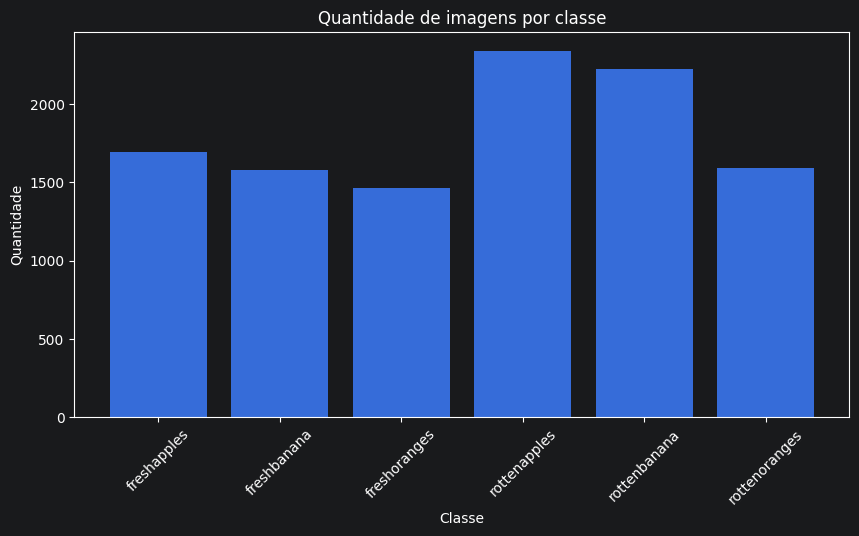

In [7]:
plt.figure(figsize=(10,5))

plt.bar(
    df_classes["classe"],
    df_classes["quantidade"]
)

plt.title("Quantidade de imagens por classe")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.xticks(rotation=45)

plt.show()

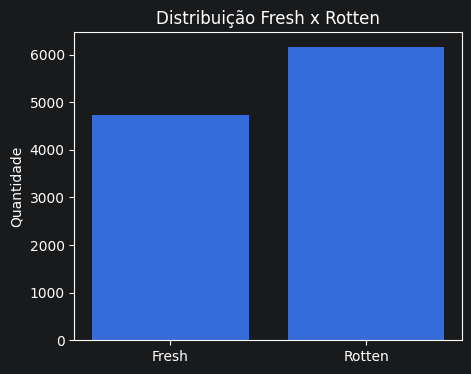

In [8]:
plt.figure(figsize=(5,4))

plt.bar(
    ["Fresh", "Rotten"],
    [fresh, rotten]
)

plt.title("Distribuição Fresh x Rotten")
plt.ylabel("Quantidade")

plt.show()

In [9]:
total = fresh + rotten

print()
print("Fresh (%):", round((fresh / total) * 100, 2))
print("Rotten (%):", round((rotten / total) * 100, 2))


Fresh (%): 43.48
Rotten (%): 56.52


## Exemplares das Classes

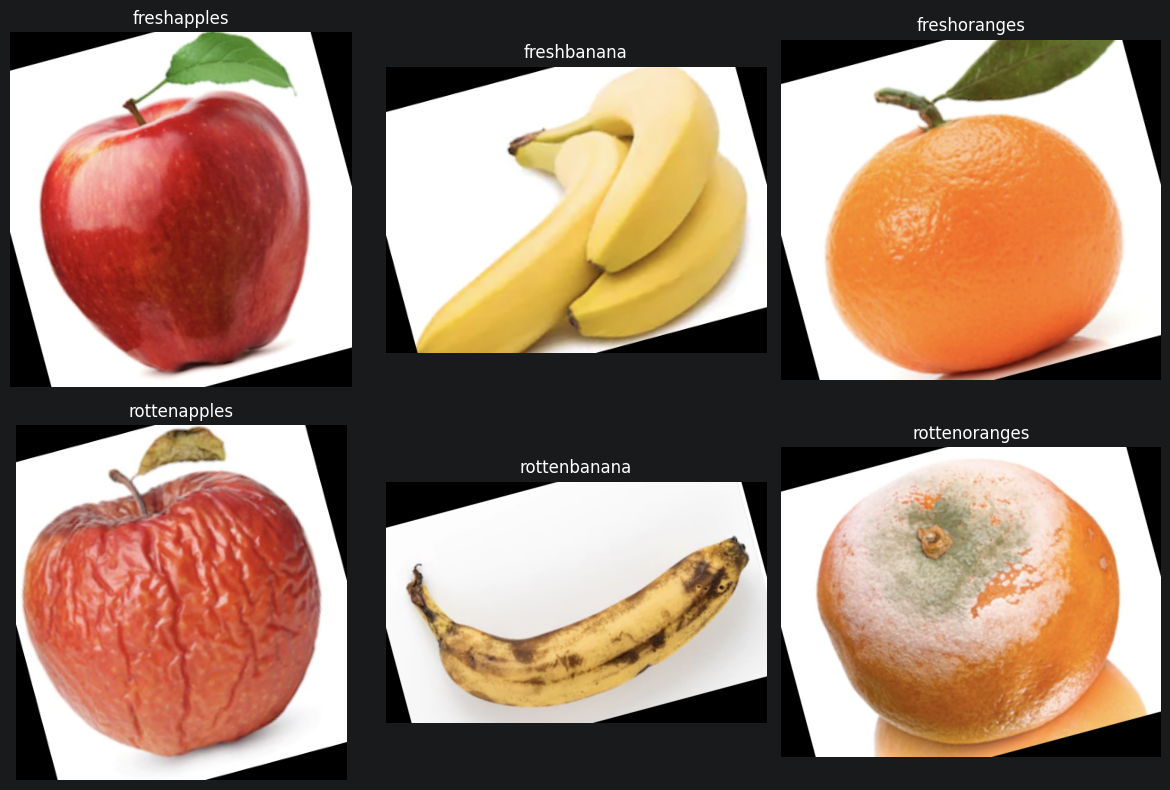

In [10]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(12,8)
)

axes = axes.ravel()

pastas = sorted([
    pasta
    for pasta in TRAIN_PATH.iterdir()
    if pasta.is_dir()
])

for ax, pasta in zip(axes, pastas):

    imagens = []

    imagens.extend(list(pasta.glob("*.jpg")))
    imagens.extend(list(pasta.glob("*.jpeg")))
    imagens.extend(list(pasta.glob("*.png")))

    img = cv2.imread(str(imagens[0]))

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(img)

    ax.set_title(pasta.name)

    ax.axis("off")

plt.tight_layout()

plt.show()

## Dimensão Imagem

In [11]:
alturas = []
larguras = []

for pasta in TRAIN_PATH.iterdir():

    if pasta.is_dir():

        imagens = []

        imagens.extend(list(pasta.glob("*.jpg")))
        imagens.extend(list(pasta.glob("*.jpeg")))
        imagens.extend(list(pasta.glob("*.png")))

        for img_path in imagens:

            img = cv2.imread(str(img_path))

            h, w = img.shape[:2]

            alturas.append(h)
            larguras.append(w)

In [12]:
# na classificação teremos que arrumar a dimensão da imagem
print("Quantidade de variação de altura: ", len(set(alturas)))

print("Quantidade de variação de largura: ", len(set(larguras))
)

Quantidade de variação de altura:  185
Quantidade de variação de largura:  290


# 🧩 | Segmentação

## 1️⃣  | Threshold e Morphology

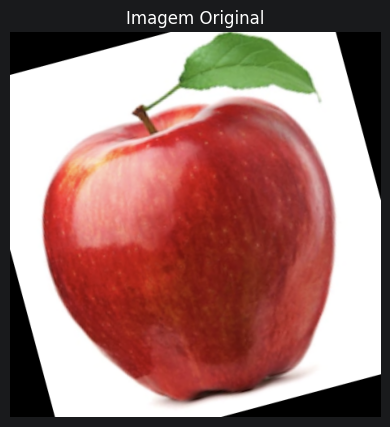

In [13]:
# IMAGEM DE TESTE

pasta_teste = sorted([
    pasta
    for pasta in TRAIN_PATH.iterdir()
    if pasta.is_dir()
])[0]

imagens = []

imagens.extend(list(pasta_teste.glob("*.jpg")))
imagens.extend(list(pasta_teste.glob("*.jpeg")))
imagens.extend(list(pasta_teste.glob("*.png")))

imagem_teste = imagens[0]

img = cv2.imread(str(imagem_teste))

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(5,5))

plt.imshow(img_rgb)

plt.title("Imagem Original")

plt.axis("off")

plt.show()

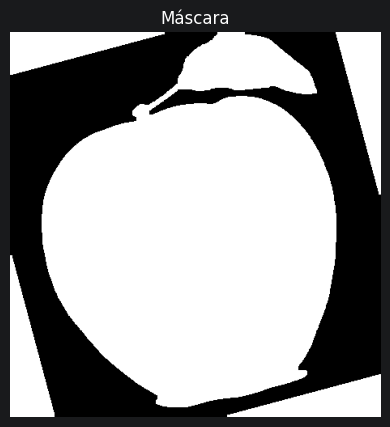

In [14]:
# SEGMENTAÇÃO

img_gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

_, mascara = cv2.threshold(
    img_gray,
    240,
    255,
    cv2.THRESH_BINARY_INV
)

kernel = np.ones((5,5), np.uint8)

mascara_limpa = cv2.morphologyEx(
    mascara,
    cv2.MORPH_OPEN,
    kernel
)

mascara_limpa = cv2.morphologyEx(
    mascara_limpa,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(5,5))

plt.imshow(
    mascara_limpa,
    cmap="gray"
)

plt.title("Máscara")

plt.axis("off")

plt.show()

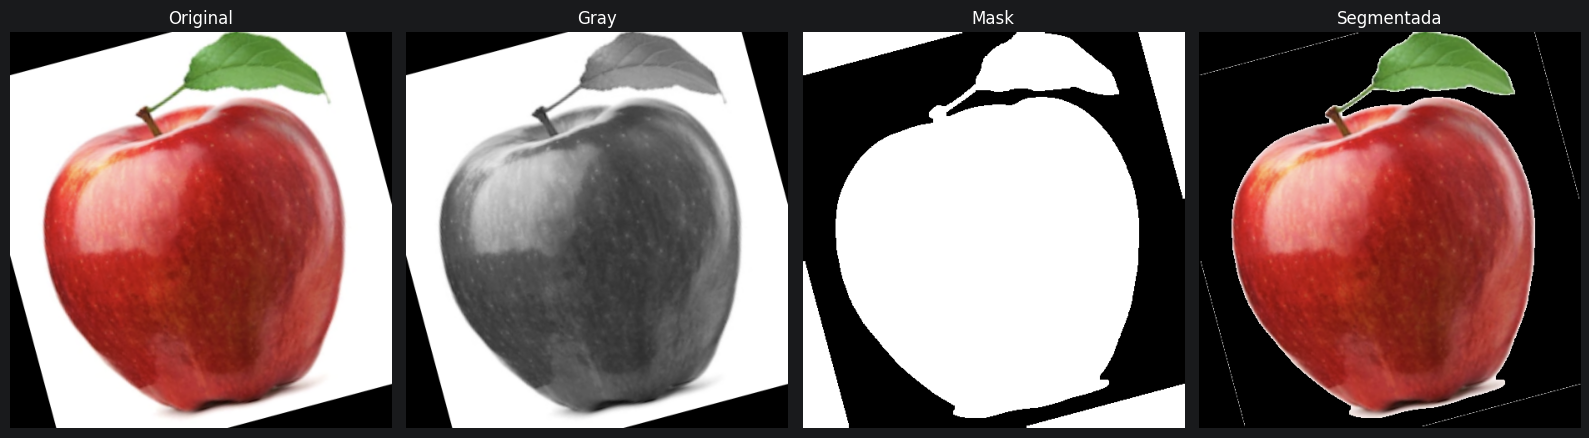

In [15]:
# RESULTADO FINAL

fruta_segmentada = cv2.bitwise_and(
    img_rgb,
    img_rgb,
    mask=mascara_limpa
)

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16,5)
)

axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(
    img_gray,
    cmap="gray"
)
axes[1].set_title("Gray")
axes[1].axis("off")

axes[2].imshow(
    mascara_limpa,
    cmap="gray"
)
axes[2].set_title("Mask")
axes[2].axis("off")

axes[3].imshow(fruta_segmentada)
axes[3].set_title("Segmentada")
axes[3].axis("off")

plt.tight_layout()

plt.show()

## 2️⃣ | HSV e Morphology

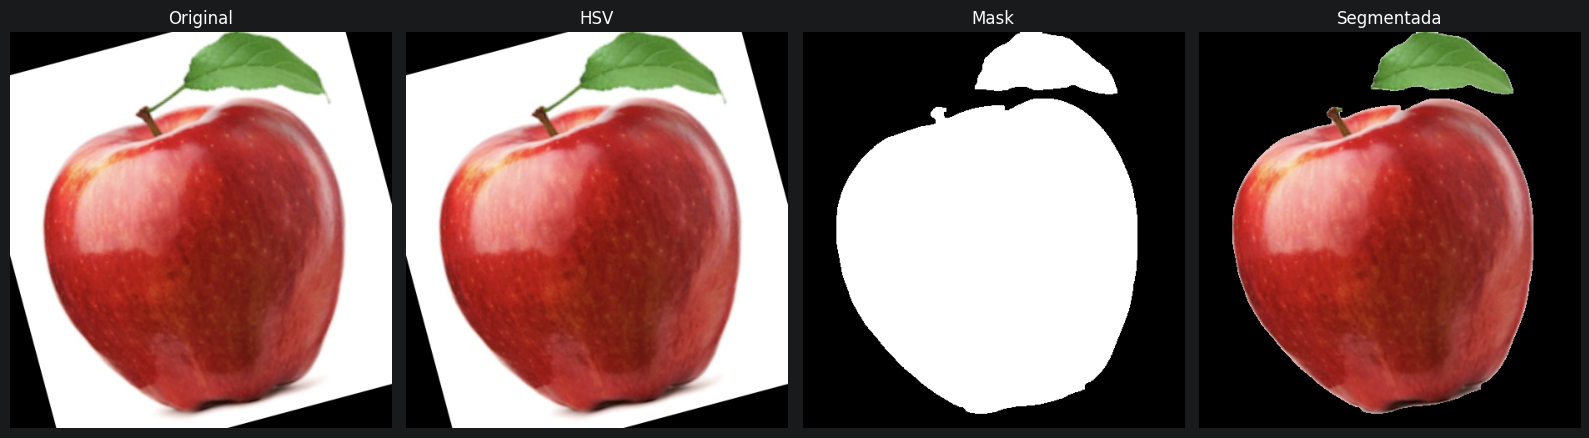

In [16]:
# agora convertendo o rgb para hsv para usar com a mask e depois  comparar os dois metodos

img_hsv = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2HSV
)

lower = np.array([
    0,
    40,
    20
])

upper = np.array([
    179,
    255,
    255
])

mascara_hsv = cv2.inRange(
    img_hsv,
    lower,
    upper
)

kernel = np.ones(
    (5,5),
    np.uint8
)

mascara_hsv_limpa = cv2.morphologyEx(
    mascara_hsv,
    cv2.MORPH_OPEN,
    kernel
)

mascara_hsv_limpa = cv2.morphologyEx(
    mascara_hsv_limpa,
    cv2.MORPH_CLOSE,
    kernel
)

fruta_segmentada_hsv = cv2.bitwise_and(
    img_rgb,
    img_rgb,
    mask=mascara_hsv_limpa
)

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16,5)
)

axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(
    cv2.cvtColor(
        img_hsv,
        cv2.COLOR_HSV2RGB
    )
)
axes[1].set_title("HSV")
axes[1].axis("off")

axes[2].imshow(
    mascara_hsv_limpa,
    cmap="gray"
)
axes[2].set_title("Mask")
axes[2].axis("off")

axes[3].imshow(fruta_segmentada_hsv)
axes[3].set_title("Segmentada")
axes[3].axis("off")

plt.tight_layout()

plt.show()

## Comparação dos Métodos


Como a imagem da maçã apresenta dois tipos de fundo, um dos métodos não obteve um bom resultado devido a essa variação. O objeto está centralizada em um quadrado branco, porém esse quadrado possui um contorno preto.

Devido a essa característica das imagens, o método Threshold + Morphology apresentou dificuldades para remover completamente o fundo, resultando em uma segmentação menos precisa da fruta.

Já o método HSV + Morphology apresentou melhor desempenho na separação entre a fruta e o fundo, preservando e Identificando a fruta e o fundo da imagem.

Com base nos resultados obtidos, foi decidido utilizar o método HSV + Morphology na etapa de extração de características.